#1 Khai báo thư viện

In [7]:
!apt-get install unrar
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


#2 Giải nén dataset

In [3]:
!unrar x /content/datasetv1.rar

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
Extracting  flower.v2i.folder/train/rose/5002460330_7286e80967_n_jpg.rf.b06886350500dd89a72f352534ae07d9.jpg      37%  OK 
Extracting  flower.v2i.folder/train/rose/5002462640_5bf92142bf_n_jpg.rf.41fad63942326d0b8eecb3bac24cf3ee.jpg      37%  OK 
Extracting  flower.v2i.folder/train/rose/5002462640_5bf92142bf_n_jpg.rf.4c3917c70fad58eee216b4fab9daf02f.jpg      37%  OK 
Extracting  flower.v2i.folder/train/rose/5002462640_5bf92142bf_n_jpg.rf.fa251c5d9af7442b126b46e9ad2ec7ff.jpg      37%  OK 
Extracting  flower.v2i.folder/train/rose/5060519573_c628547e20_n_jpg.rf.0b671902184d512f4624f253e4cf6188.jpg      37%  OK 
Extracting  flower.v2i.folder/train/rose/5060519573_c628547e20_n_jpg.rf.1eec3e0dd01be80e35a647f7ce3ea9b5.jpg      37%  OK 
Extracting  flower.v2i.folder/train/rose/5060519573_c628547e20_n_jpg.rf.bfcd56fa42debe398b42e38776081725.jpg      37%  OK 
Extracting  flower.

#3 Tiền xử lý dữ liệu

In [22]:
train_dir = "/content/datasetv1/train"
valid_dir = "/content/datasetv1/valid"
test_dir  = "/content/datasetv1/test"
# Chuẩn hóa giá trị điểm ảnh về khoảng [0, 1]
train_data_gen = ImageDataGenerator(rescale=1./255)
valid_data_gen = ImageDataGenerator(rescale=1./255)
test_data_gen  = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64 # Số lượng ảnh cho lần huấn luyện
IMG_SIZE = (224, 224) # Kích thước ảnh đầu vào

print("Đang nạp dữ liệu Huấn luyện (Train)...")
train_generator = train_data_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Đang nạp dữ liệu Kiểm định (Validation)...")
validation_generator = valid_data_gen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Đang nạp dữ liệu Kiểm thử (Test)...")
test_generator = test_data_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Không xáo trộn dữ liệu test để thuận tiện cho việc so sánh kết quả sau này
)
# In ra danh sách các nhãn (4 loại hoa)
labels = list(train_generator.class_indices.keys())
print("Các nhãn hoa được nhận diện:", labels)

Đang nạp dữ liệu Huấn luyện (Train)...
Found 7554 images belonging to 4 classes.
Đang nạp dữ liệu Kiểm định (Validation)...
Found 698 images belonging to 4 classes.
Đang nạp dữ liệu Kiểm thử (Test)...
Found 346 images belonging to 4 classes.
Các nhãn hoa được nhận diện: ['Sunflower', 'dandelion', 'rose', 'tulip']


#4 Kiến trúc mô hình

In [23]:
# 1. Khởi tạo cấu trúc mô hình tuần tự (Sequential)
model = Sequential([
    # Tầng vào (Input Layer) cấu hình cho ảnh độ phân giải mới 224x224, 3 kênh màu RGB
    keras.layers.Input(shape=(224, 224, 3)),

    # Khối CNN 1: Trích xuất các đặc trưng hình học cơ bản (Cạnh, góc, nét thẳng)
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)), # Kích thước ảnh giảm còn 112x112

    # Khối CNN 2: Học các cấu trúc hình học phức tạp hơn
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)), # Kích thước ảnh giảm còn 56x56

    # Khối CNN 3: Bắt đầu học các chi tiết của cánh hoa, nhụy hoa
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)), # Kích thước ảnh giảm còn 28x28
    Dropout(0.25),        # Ngắt ngẫu nhiên 25% node để chống học vẹt

    # Khối CNN 4: Học các đặc trưng trừu tượng ở phạm vi rộng hơn
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)), # Kích thước ảnh giảm còn 14x14

    # Khối CNN 5: Khối trích xuất đặc trưng sâu cuối cùng trước khi phân loại
    Conv2D(512, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)), # Kích thước ảnh giảm còn 7x7
    Dropout(0.25),

    # Nén ma trận đặc trưng (7, 7, 512) thành một vector phẳng chỉ gồm 512 phần tử
    GlobalAveragePooling2D(),

    # Tầng ẩn liên kết đầy đủ (Fully Connected Layer) để phân tích các đặc trưng đã học
    Dense(256, activation='relu'),
    Dropout(0.5), # Ngắt nâng cao 50% trước khi đưa ra quyết định cuối cùng

    # Tầng đầu ra (Output Layer): Cấu hình 4 node tương ứng với 4 loại hoa cần nhận diện
    Dense(4, activation='softmax')
])

# 2. Thiết lập thuật toán tối ưu và hàm mất mát để huấn luyện
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Sử dụng thuật toán Adam 
    loss='categorical_crossentropy',                         # Hàm mất mát cho bài toán phân loại đa lớp
    metrics=['accuracy']                                     # Thước đo đánh giá là độ chính xác (Accuracy)
)

# 3. In bảng tóm tắt chi tiết cấu trúc mạng để kiểm tra tham số
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,700,932 (6.49 MB)

 Trainable params: 1,700,932 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

#5 Huấn luyện mô hình

In [24]:
EPOCHS = 50 #Số lần lặp

print("\n--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---")
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,)


--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH ---
Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - accuracy: 0.4817 - loss: 1.1258 - val_accuracy: 0.6304 - val_loss: 0.9210
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 268ms/step - accuracy: 0.5864 - loss: 0.9118 - val_accuracy: 0.6318 - val_loss: 0.8568
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 276ms/step - accuracy: 0.6632 - loss: 0.7768 - val_accuracy: 0.6991 - val_loss: 0.7308
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 35s 291ms/step - accuracy: 0.7084 - loss: 0.7082 - val_accuracy: 0.7149 - val_loss: 0.6906
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 271ms/step - accuracy: 0.7342 - loss: 0.6585 - val_accuracy: 0.7249 - val_loss: 0.6815
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 275ms/step - accuracy: 0.7555 - loss: 0.6233 - val_accuracy: 0.7521 - val_loss: 0.6046
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 264ms/step - accuracy: 0.7769 - loss: 0.5675 - val_accuracy: 0.7779 - val_loss: 0.5812
Epoch 8/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 277

#6 Trực quan hóa quá trình huấn luyện

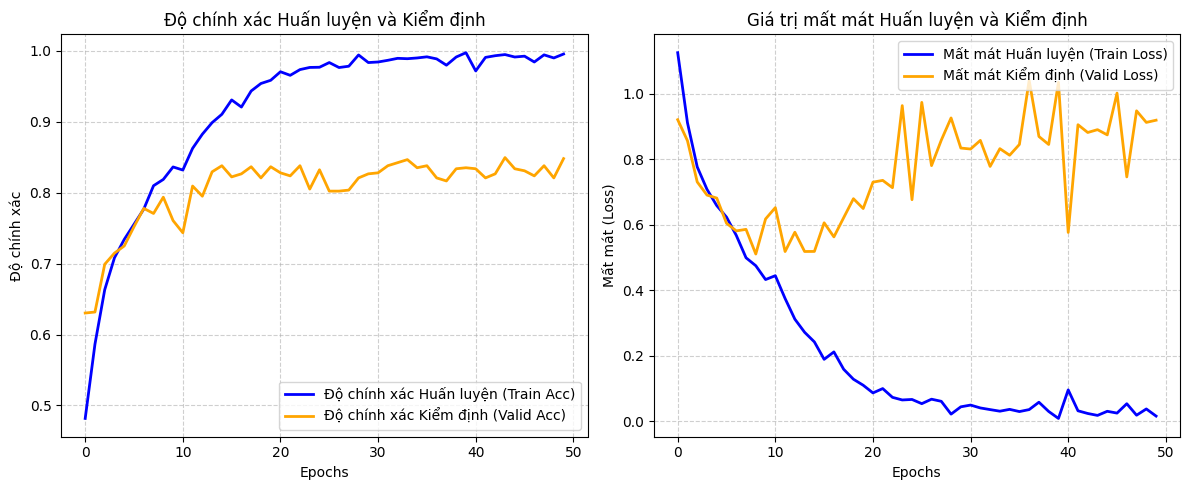

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Lấy tổng số Epochs thực tế đã chạy
epochs_range = range(len(acc))

# Khởi tạo khung vẽ đồ thị có kích thước 12x5
plt.figure(figsize=(12, 5))

# 1. Vẽ đồ thị biểu diễn Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Độ chính xác Huấn luyện (Train Acc)', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Độ chính xác Kiểm định (Valid Acc)', color='orange', linewidth=2)
plt.legend(loc='lower right')
plt.title('Độ chính xác Huấn luyện và Kiểm định')
plt.xlabel('Epochs')
plt.ylabel('Độ chính xác')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Vẽ đồ thị biểu diễn Giá trị mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Mất mát Huấn luyện (Train Loss)', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Mất mát Kiểm định (Valid Loss)', color='orange', linewidth=2)
plt.legend(loc='upper right')
plt.title('Giá trị mất mát Huấn luyện và Kiểm định')
plt.xlabel('Epochs')
plt.ylabel('Mất mát (Loss)')
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị đồ thị
plt.tight_layout()
plt.show()

#7 Kiểm tra mô hình

In [26]:
print("--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP KIỂM THỬ ---")
loss, accuracy = model.evaluate(test_generator)
print(f"Loss trên tập kiểm thử: {loss:.4f}")
print(f"Độ chính xác trên tập kiểm thử: {accuracy:.4f}")

--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP KIỂM THỬ ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 586ms/step - accuracy: 0.8757 - loss: 0.9289
Loss trên tập kiểm thử: 0.9289
Độ chính xác trên tập kiểm thử: 0.8757


### #8 Dự đoán trên ảnh thực tế
Sử dụng đoạn mã này để tải lên một tệp ảnh từ máy tính của bạn và kiểm tra kết quả dự đoán của mô hình.

Saving tải xuống (3).jpg to tải xuống (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


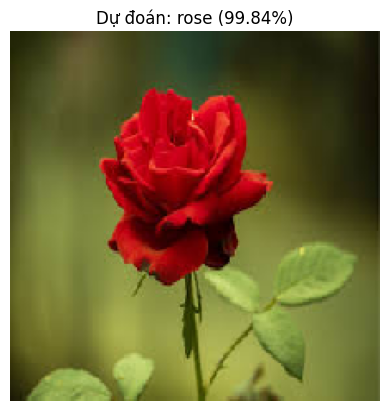

In [30]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_uploaded_image(model, img_size=(224, 224), labels=None):
    uploaded = files.upload()

    for fn in uploaded.keys():
        # Load và tiền xử lý ảnh
        path = fn
        img = image.load_img(path, target_size=img_size)
        x = image.img_to_array(img)
        x = x / 255.0  # Chuẩn hóa giống lúc train
        x = np.expand_dims(x, axis=0)

        # Dự đoán
        classes = model.predict(x)
        result_idx = np.argmax(classes[0])
        confidence = classes[0][result_idx] * 100

        # Hiển thị kết quả
        plt.imshow(img)
        plt.axis('off')
        if labels:
            plt.title(f"Dự đoán: {labels[result_idx]} ({confidence:.2f}%)")
        else:
            plt.title(f"Class index: {result_idx} ({confidence:.2f}%)")
        plt.show()

# Gọi hàm để bắt đầu kiểm thử
predict_uploaded_image(model, IMG_SIZE, labels)